# Inferência — previsão de horizonte (3-4 semanas)

## Objetivo

Carregar os artefatos gerados por `modelagem_06_final_treino.ipynb` e
produzir previsões para um horizonte de 4 semanas à frente, por produto e
estado, prontas para consumo pela aplicação Streamlit.

**Este notebook deve ser executado com a mesma versão dos artefatos gerados
pelo notebook de treino.** Qualquer retreino deve reexportar
`models/modelo_producao_<produto>_lgbm.json`, `models/colunas_<produto>_lgbm.json`,
`resultados/mae_por_produto_estado.csv` e `resultados/clusters_por_produto.json`
antes de rodar este notebook novamente.

In [1]:
import os
import json

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

PRODUTOS = ["GLP", "GASOLINA", "ETANOL", "DIESEL"]

REPO_ROOT = os.getcwd()[:-4] if os.getcwd().endswith(r"\src") else os.getcwd()
PASTA_MODELOS = os.path.join(REPO_ROOT, "models")
PASTA_RESULTADOS = os.path.join(REPO_ROOT, "resultados")

with open(os.path.join(PASTA_RESULTADOS, "clusters_por_produto.json")) as f:
    CLUSTERS_POR_PRODUTO = json.load(f)

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: C:\Users\ferna\Dev\Projetos\GitHub\ANP


## 1. Carregar os 4 modelos e suas colunas de referência

In [2]:
modelos = {}
colunas_modelo = {}

for produto in PRODUTOS:
    sufixo = produto.lower()
    modelos[produto] = lgb.Booster(
        model_file=os.path.join(PASTA_MODELOS, f"modelo_producao_{sufixo}_lgbm.json")
    )
    with open(os.path.join(PASTA_MODELOS, f"colunas_{sufixo}_lgbm.json")) as f:
        colunas_modelo[produto] = json.load(f)

    print(f"{produto}: {len(colunas_modelo[produto])} colunas")

GLP: 22 colunas
GASOLINA: 22 colunas
ETANOL: 22 colunas
DIESEL: 22 colunas


## 2. Carregar a tabela de MAE por produto × estado

In [3]:
df_mae = pd.read_csv(os.path.join(PASTA_RESULTADOS, "mae_por_produto_estado.csv"))
df_mae = df_mae.rename(columns={"mae_estado": "mae_modelo_estado"})
df_mae.head()

,produto,estado,mae_modelo_estado,mae_baseline_estado
0,DIESEL,AC,0.180247,0.178958
1,DIESEL,AL,0.226978,0.214583
2,DIESEL,AM,0.091659,0.051250
3,DIESEL,AP,0.090074,0.025208
4,DIESEL,BA,0.103096,0.093542


## 3. Carregar o histórico mais recente por produto × estado

Usamos a base tratada bruta (antes da codificação de cluster/dummies),
que preserva a coluna `Estado - Sigla` original — necessária para separar
a série de cada estado individualmente antes de aplicar o cluster do
produto na hora de montar o vetor de features. O histórico completo tem
muito mais que as 27 semanas mínimas exigidas pelo `lag_27`.

In [4]:
path_dados = os.path.join(REPO_ROOT, "data", "dados_anp_modelado.parquet")

df_historico = pd.read_parquet(path_dados)
df_historico.index = df_historico["dt_week"]
df_historico = df_historico.drop(columns=["dt_week"]).sort_index()

print(df_historico.shape)
print(df_historico.index.min(), "até", df_historico.index.max())

(100224, 30)
2008-07-14/2008-07-20 até 2026-07-27/2026-08-02


## 4. Função de previsão recursiva

Constrói, semana a semana, o vetor de features esperado pelo modelo:
- `lag_1 ... lag_27`: alimentados recursivamente a partir do histórico real
  + previsões já geradas nos passos anteriores do próprio horizonte.
- `rolling_mean_N` / `rolling_std_N` (N=4,8,12): calculados sobre a mesma
  janela de preços (real + já previsto), replicando a definição usada no
  treino (`price_sale_median.shift(1).rolling(N)` — média/desvio das N
  semanas *anteriores* à que está sendo prevista, nunca incluindo a
  própria semana-alvo, confirmado empiricamente contra os dados de treino).
- Exógenas (dólar, Brent, IPCA, SELIC, PIB): **congeladas no último valor
  conhecido** durante todo o horizonte — limitação documentada no README e
  reforçada abaixo.
- Cluster: a dummy de cluster correta para o `produto`/`estado` (via
  `CLUSTERS_POR_PRODUTO`), as demais zeradas.

Gera tanto a previsão do modelo quanto a do baseline de persistência
(`lag_1` projetado — ou seja, o último preço real repetido ao longo de
todo o horizonte), para exibição lado a lado por transparência
metodológica.

In [5]:
LAGS = [1, 2, 3, 4, 8, 27]
JANELAS = [4, 8, 12]
EXOG_COLS = ["Valor Venda Dolar", "Valor Compra Dolar", "Close_BZ=F", "ipca", "pib_mensal", "selic"]
MIN_HISTORICO = 27


def prever_horizonte(produto, estado, df_historico, modelos, colunas_modelo,
                      clusters_por_produto, n_semanas=4):
    """
    Retorna um DataFrame com colunas:
    produto, estado, semana, preco_modelo, preco_baseline
    """
    cluster = clusters_por_produto[produto].get(estado)
    if cluster is None:
        raise ValueError(f"Estado {estado} sem cluster mapeado para {produto}")

    serie = (
        df_historico[
            (df_historico["Produto"] == produto) & (df_historico["Estado - Sigla"] == estado)
        ]
        .sort_index()
    )
    if len(serie) < MIN_HISTORICO:
        raise ValueError(
            f"Histórico insuficiente para {produto}/{estado}: "
            f"{len(serie)} semanas (mínimo {MIN_HISTORICO})"
        )

    precos = serie["price_sale_median"].tolist()
    exogenas_congeladas = serie.iloc[-1][EXOG_COLS].to_dict()
    preco_baseline = precos[-1]  # persistência: último preço real, fixo no horizonte
    semana = serie.index[-1]
    colunas = colunas_modelo[produto]
    modelo = modelos[produto]

    linhas = []
    for _ in range(n_semanas):
        feats = {f"price_sale_median_lag_{l}": precos[-l] for l in LAGS}
        for j in JANELAS:
            janela = precos[-j:]
            feats[f"price_sale_median_rolling_mean_{j}"] = float(np.mean(janela))
            feats[f"rolling_std_{j}"] = float(np.std(janela, ddof=1))
        feats.update(exogenas_congeladas)
        for c in colunas:
            if c.startswith("cluster_"):
                feats[c] = 1 if c == f"cluster_{cluster}" else 0

        X = pd.DataFrame([feats])[colunas]
        residuo_previsto = modelo.predict(X)[0]
        preco_modelo = precos[-1] + residuo_previsto
        precos.append(preco_modelo)

        semana = semana + 1
        linhas.append({
            "produto": produto,
            "estado": estado,
            "semana": str(semana),
            "preco_modelo": preco_modelo,
            "preco_baseline": preco_baseline,
        })

    return pd.DataFrame(linhas)

## 5 e 6. Geração da tabela final de previsões (todos os produtos × estados)

In [6]:
N_SEMANAS = 4
todas_previsoes = []

for produto in PRODUTOS:
    estados_produto = sorted(df_historico[df_historico["Produto"] == produto]["Estado - Sigla"].unique())
    for estado in estados_produto:
        prev = prever_horizonte(
            produto, estado, df_historico, modelos, colunas_modelo,
            CLUSTERS_POR_PRODUTO, n_semanas=N_SEMANAS,
        )
        todas_previsoes.append(prev)

df_previsoes_final = pd.concat(todas_previsoes, ignore_index=True)
df_previsoes_final = df_previsoes_final.merge(df_mae, on=["produto", "estado"], how="left")

df_previsoes_final.to_csv(os.path.join(PASTA_RESULTADOS, "previsoes_horizonte.csv"), index=False)

print(df_previsoes_final.shape)
df_previsoes_final.head(10)

(432, 7)


,produto,estado,semana,preco_modelo,preco_baseline,mae_modelo_estado,mae_baseline_estado
0,GLP,AC,2026-08-03/2026-08-09,126.117402,126.0,1.385679,1.270833
1,GLP,AC,2026-08-10/2026-08-16,126.234804,126.0,1.385679,1.270833
2,GLP,AC,2026-08-17/2026-08-23,126.293152,126.0,1.385679,1.270833
3,GLP,AC,2026-08-24/2026-08-30,126.351500,126.0,1.385679,1.270833
4,GLP,AL,2026-08-03/2026-08-09,105.034113,105.0,0.890654,0.833333
5,GLP,AL,2026-08-10/2026-08-16,105.068225,105.0,0.890654,0.833333
6,GLP,AL,2026-08-17/2026-08-23,105.102338,105.0,0.890654,0.833333
7,GLP,AL,2026-08-24/2026-08-30,105.136450,105.0,0.890654,0.833333
8,GLP,AM,2026-08-03/2026-08-09,126.060172,126.0,0.493219,0.416667
9,GLP,AM,2026-08-10/2026-08-16,126.120344,126.0,0.493219,0.416667


## 7. Validação final (sanity check)

In [7]:
n_estados_total = sum(
    df_historico[df_historico["Produto"] == p]["Estado - Sigla"].nunique() for p in PRODUTOS
)
esperado = n_estados_total * N_SEMANAS
assert len(df_previsoes_final) == esperado, (
    f"Esperado {esperado} linhas ({n_estados_total} produto×estado x {N_SEMANAS} semanas), "
    f"encontrado {len(df_previsoes_final)}"
)

assert df_previsoes_final["preco_modelo"].isnull().sum() == 0
assert df_previsoes_final["preco_baseline"].isnull().sum() == 0

print(f"Sanity check OK: {len(df_previsoes_final)} linhas, sem NaN em preco_modelo/preco_baseline.")

Sanity check OK: 432 linhas, sem NaN em preco_modelo/preco_baseline.


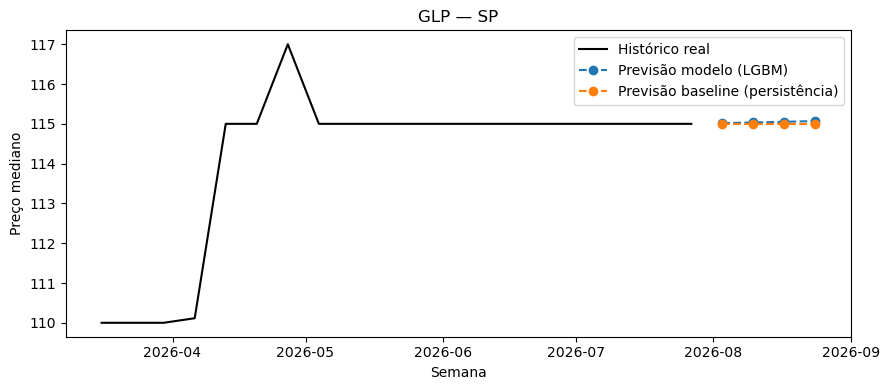

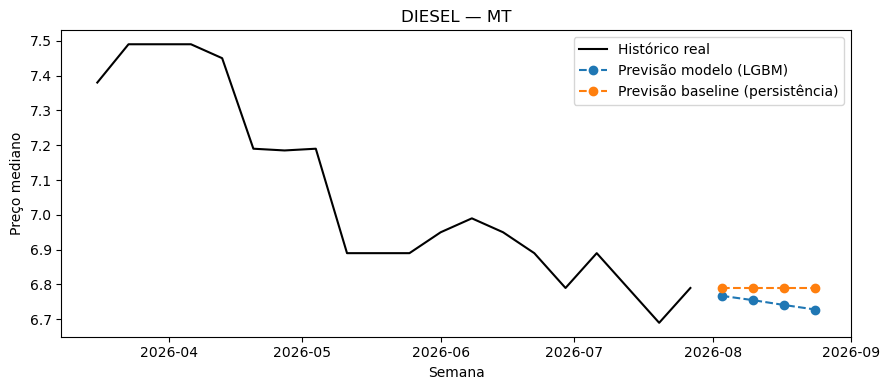

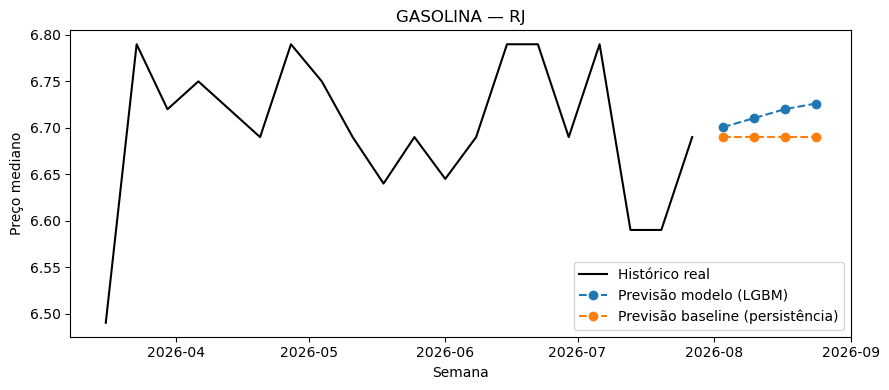

In [8]:
def plotar_exemplo(produto, estado, n_semanas_historico=20):
    serie = (
        df_historico[
            (df_historico["Produto"] == produto) & (df_historico["Estado - Sigla"] == estado)
        ]
        .sort_index()
        .tail(n_semanas_historico)
    )
    prev = df_previsoes_final[
        (df_previsoes_final["produto"] == produto) & (df_previsoes_final["estado"] == estado)
    ]

    x_hist = serie.index.to_timestamp()
    x_prev = pd.PeriodIndex(prev["semana"].str.split("/").str[0], freq="W-SUN").to_timestamp()

    plt.figure(figsize=(9, 4))
    plt.plot(x_hist, serie["price_sale_median"], label="Histórico real", color="black")
    plt.plot(x_prev, prev["preco_modelo"], "o--", label="Previsão modelo (LGBM)", color="tab:blue")
    plt.plot(x_prev, prev["preco_baseline"], "o--", label="Previsão baseline (persistência)", color="tab:orange")
    plt.title(f"{produto} — {estado}")
    plt.xlabel("Semana")
    plt.ylabel("Preço mediano")
    plt.legend()
    plt.tight_layout()
    plt.show()


for produto, estado in [("GLP", "SP"), ("DIESEL", "MT"), ("GASOLINA", "RJ")]:
    plotar_exemplo(produto, estado)

## Observações metodológicas

- **Exógenas congeladas:** dólar, Brent, IPCA, SELIC e PIB mensal são
  mantidos no último valor conhecido durante todo o horizonte de previsão.
  Isso significa que a previsão do modelo não reage a possíveis mudanças
  futuras nessas variáveis — limitação já discutida no README quanto à
  mudança de patamar do Brent entre 2024 e 2025-2026, fora do range visto
  no treino.
- **Baseline sempre ao lado do modelo:** qualquer consumo posterior desta
  tabela (Streamlit) deve exibir `preco_baseline` junto de `preco_modelo`.
  Como documentado no README, nenhum modelo testado neste projeto superou
  o baseline de persistência de forma consistente — omitir essa
  comparação na interface final seria enganoso quanto à real utilidade do
  modelo.
- **Consistência de artefatos:** este notebook assume que
  `models/modelo_producao_*_lgbm.json`, `models/colunas_*_lgbm.json`,
  `resultados/mae_por_produto_estado.csv` e
  `resultados/clusters_por_produto.json` vêm da mesma execução de
  `modelagem_06_final_treino.ipynb`. Um retreino sem reexportar esses
  arquivos gera inconsistência silenciosa entre o modelo e a tabela de MAE
  exibida ao usuário.